# Denoising

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import skimage.io as io
from skimage.util import img_as_float, random_noise
from skimage.color import rgb2gray
from skimage.filters import gaussian, median
from skimage.transform import resize
from scipy.ndimage import convolve
from numpy.fft import fft2, fftshift, ifftshift, ifft2
from skimage.restoration import denoise_tv_chambolle

In [2]:
def display(num, img, title):
    axs[0][num].imshow(img, cmap="gray")
    axs[0][num].set_title(title, fontsize=16)
    axs[0][num].set_xticks([])
    axs[0][num].set_yticks([])
    axs[1][num].imshow(img[17:47,58:88], cmap="gray")
    axs[1][num].set_xticks([])
    axs[1][num].set_yticks([])

## Mean & median filters

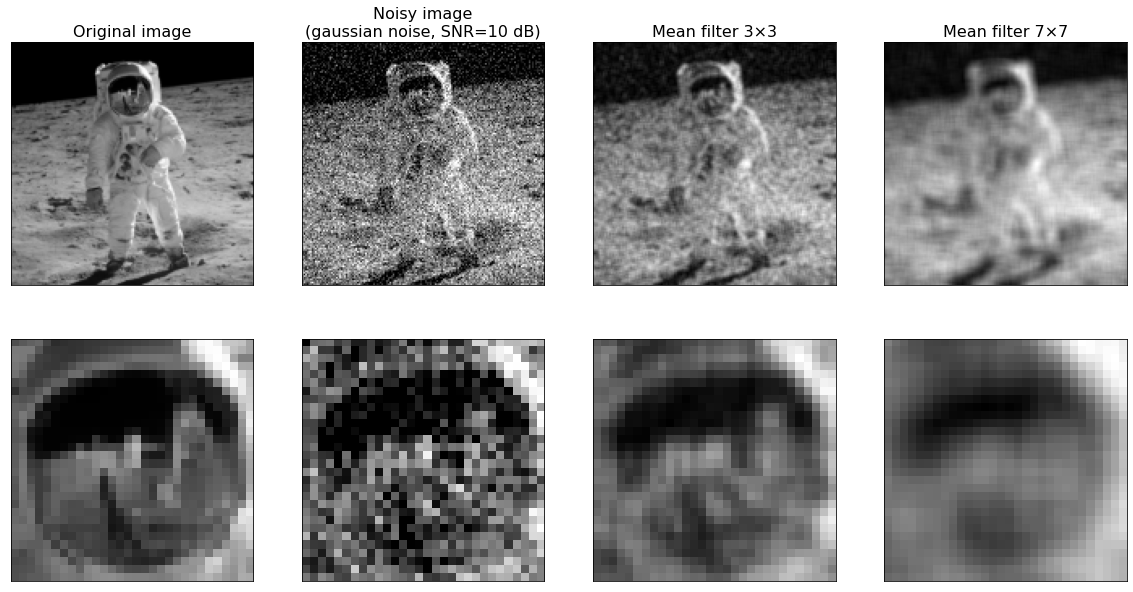

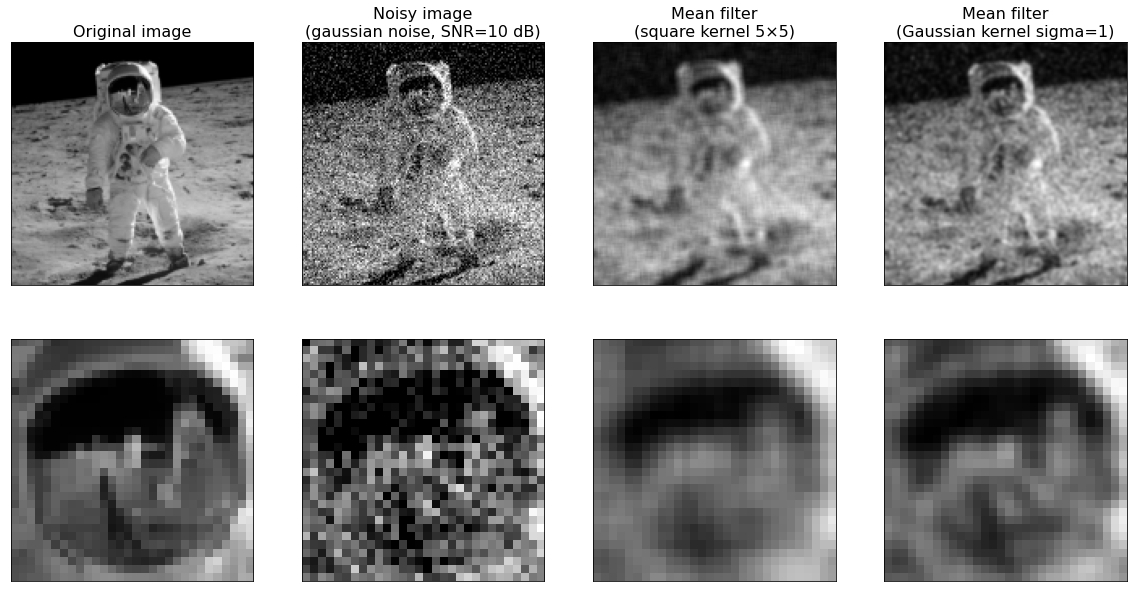

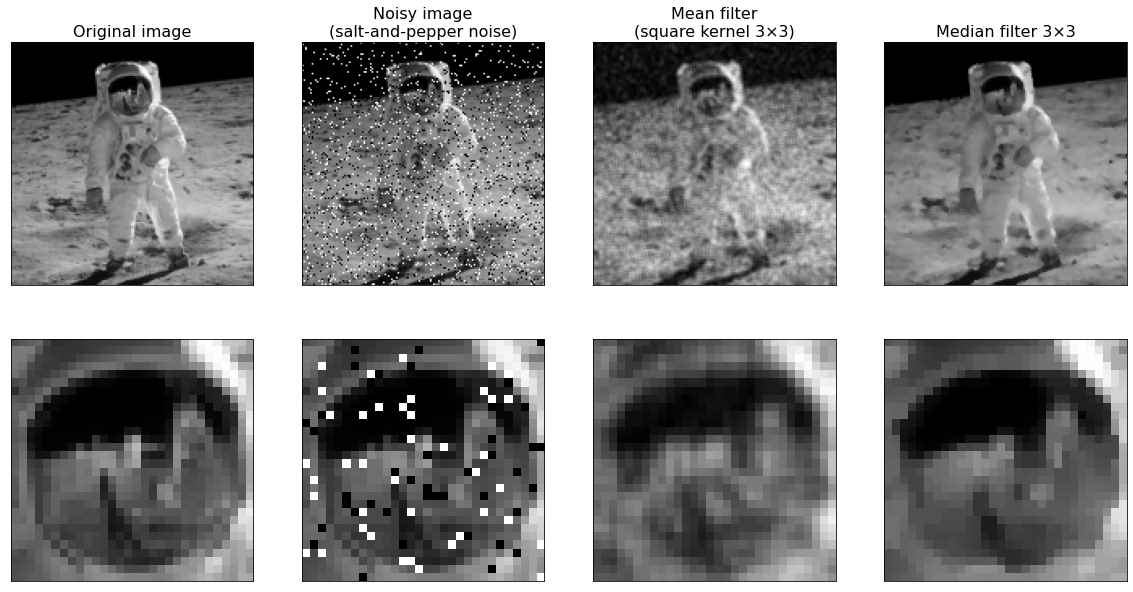

In [3]:
def square_footprint(s):
    return np.ones((s,s)) / s**2

# Original image
original = io.imread('aldrin.png')
original = resize(original, (150, 150), order=1, anti_aliasing=True)
original = img_as_float(original)

# Image with Gaussian noise
gaussian_noisy = random_noise(original, mode='gaussian', clip=True, var=.025)
noise = gaussian_noisy - original
snr = 10 * np.log10( np.mean(original**2) / np.mean(noise**2) )

# Salt-and-pepper noise
sp_noisy = random_noise(original, mode='s&p', clip=True, amount=.1)

# Mean filter (square kernel)
mean_filter_3 = convolve(gaussian_noisy, square_footprint(3))
mean_filter_5 = convolve(gaussian_noisy, square_footprint(5))
mean_filter_7 = convolve(gaussian_noisy, square_footprint(7))

# Mean filter (Gaussian kernel)
gaussian_filter_1 = gaussian(gaussian_noisy,1)

# Median filter
median_filter_3 = median(sp_noisy, square_footprint(3))

# Mean filter
fig, axs = plt.subplots(2, 4, figsize=(20,10))
display(0, original, "Original image")
display(1, gaussian_noisy, f"Noisy image\n(gaussian noise, SNR={snr:.0f} dB)")
display(2, mean_filter_3, "Mean filter 3×3")
display(3, mean_filter_7, "Mean filter 7×7")
fig.savefig("mean-filter-size.svg", bbox_inches='tight')
plt.show()

# Mean filter with different footprints
fig, axs = plt.subplots(2, 4, figsize=(20,10))
display(0, original, "Original image")
display(1, gaussian_noisy, f"Noisy image\n(gaussian noise, SNR={snr:.0f} dB)")
display(2, mean_filter_5, "Mean filter\n(square kernel 5×5)")
display(3, gaussian_filter_1, "Mean filter\n(Gaussian kernel sigma=1)")
fig.savefig("mean-filter-kernels.svg", bbox_inches='tight')
plt.show()

# Median filter vs mean filter
fig, axs = plt.subplots(2, 4, figsize=(20,10))
display(0, original, "Original image")
display(1, sp_noisy, "Noisy image\n(salt-and-pepper noise)")
display(2, mean_filter_3, "Mean filter\n(square kernel 3×3)")
display(3, median_filter_3, "Median filter 3×3")
fig.savefig("median-vs-mean.svg", bbox_inches='tight')
plt.show()

## Periodic noise

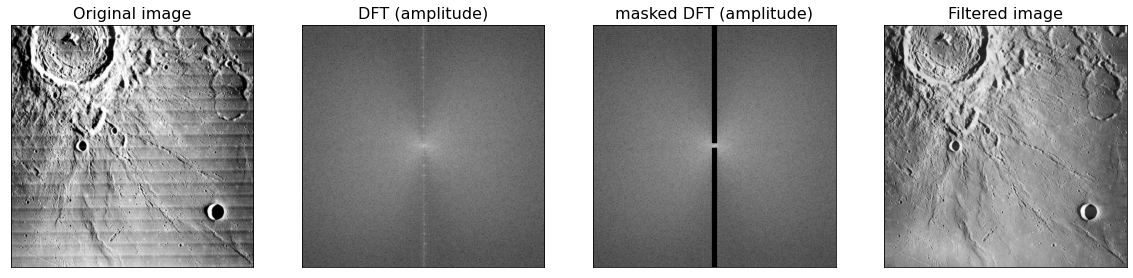

In [4]:
img = io.imread('lo1_m31.jpg')
img = img[20:520,20:520]

F = fftshift(fft2(img))

mask = np.ones(F.shape)
mask[:245,245:255] = 1e-9
mask[255:,245:255] = 1e-9
G = F*mask

res = np.real(ifft2(ifftshift(G)))

fig, axs = plt.subplots(1,4,figsize=(20,5))
axs[0].imshow(img, cmap="gray")
axs[0].set_title('Original image', fontsize=16)
axs[1].imshow(20*np.log10(abs(F)), cmap="gray", vmin=23, vmax=151)
axs[1].set_title('DFT (amplitude)', fontsize=16)
axs[2].imshow(20*np.log10(abs(G)), cmap="gray", vmin=23, vmax=151)
axs[2].set_title('masked DFT (amplitude)', fontsize=16)
axs[3].imshow(res, cmap="gray")
axs[3].set_title('Filtered image', fontsize=16)
for i in range(4):
    axs[i].set_xticks([])
    axs[i].set_yticks([])
plt.savefig("periodic-noise.svg", bbox_inches='tight')
plt.show()

(740, 560)
0 1


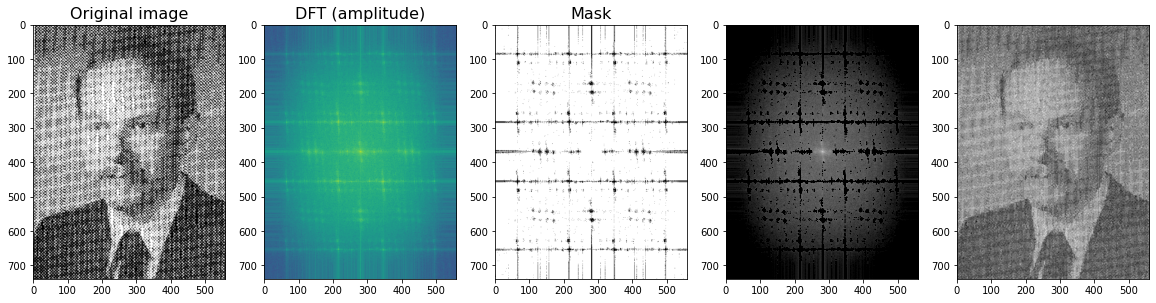

In [56]:
img = io.imread('theriault.png')
img = img[50:790,40:600]
img = rgb2gray(img)
print(img.shape)

F = fftshift(fft2(img))

from skimage.filters import threshold_local
X = 20*np.log10(abs(F))
T = threshold_local(X, 101, offset=-10)
Mask = (X<T)*1
Mask[340:400,250:310] = 1

# Mask = T>30

# Mask = np.ones(F.shape)
# Mask[280:290,:] = 0
# Mask[450:460,:] = 0
# Mask[360:380,:220] = 0
# Mask[360:380,330:] = 0

print(Mask.min(), Mask.max())
Y = F*Mask + 1e-12

y = np.real(ifft2(ifftshift(Y)))

fig, axs = plt.subplots(1,5,figsize=(20,5))
axs[0].imshow(img, cmap="gray")
axs[0].set_title('Original image', fontsize=16)
axs[1].imshow(20*np.log10(abs(F)))
axs[1].set_title('DFT (amplitude)', fontsize=16)
axs[2].imshow(Mask, cmap="gray")
axs[2].set_title('Mask', fontsize=16)
axs[3].imshow(20*np.log10(abs(Y)), cmap="gray", vmin=5)
axs[3].set_title('', fontsize=16)
axs[4].imshow(y, cmap="gray")
axs[4].set_title('', fontsize=16)
plt.show()

# TV regularisation

In [63]:
from numpy import arange
from skimage.io import imread, imsave
from skimage.color import rgb2gray
from matplotlib.pyplot import imshow, show

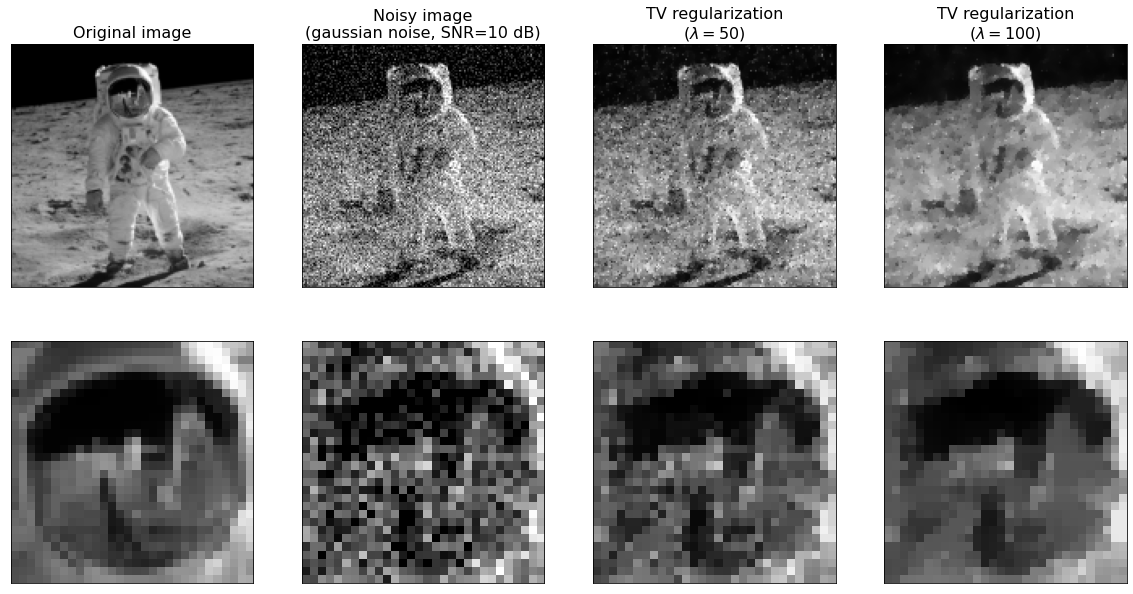

In [75]:
img = io.imread('aldrin.png')
img = resize(img, (150, 150), order=1, anti_aliasing=True)
img = img_as_float(img)

obs = random_noise(img, mode='gaussian', clip=True, var=.025)
noise = obs - img
snr = 10 * np.log10( np.mean(img**2) / np.mean(noise**2) )

lbd1 = 50
restored_1 = denoise_tv_chambolle(obs, weight=lbd1/1000)

lbd2 = 100
restored_2 = denoise_tv_chambolle(obs, weight=lbd2/1000)

fig, axs = plt.subplots(2, 4, figsize=(20,10))
display(0, img, "Original image")
display(1, obs, f"Noisy image\n(gaussian noise, SNR={snr:.0f} dB)")
display(2, restored_1, f"TV regularization\n($\lambda = {lbd1}$)")
display(3, restored_2, f"TV regularization\n($\lambda = {lbd2}$)")
fig.savefig("tv-denoising.svg", bbox_inches='tight')
plt.show()